# Productivity Analysis & Performance Trends

## Objective
Analyze workforce productivity metrics and track performance improvement over time.

## Key Questions
1. What is our productivity by department and role?
2. How does productivity correlate with performance ratings?
3. Which employees are improving vs. declining in performance?
4. How effective are performance improvement plans (PIPs)?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Load data
print("Loading data...")
workforce = pd.read_csv('../data/current_workforce.csv')
productivity = pd.read_csv('../data/productivity_metrics.csv')
reviews = pd.read_csv('../data/performance_reviews.csv')
pips = pd.read_csv('../data/pips.csv')

print(f"Workforce: {len(workforce)} employees")
print(f"Productivity metrics: {len(productivity)} records")
print(f"Performance reviews: {len(reviews)} records")
print(f"PIPs: {len(pips)} records")

Loading data...
Workforce: 500 employees
Productivity metrics: 500 records
Performance reviews: 2361 records
PIPs: 63 records


## 1. How We Measure Productivity

### Productivity Measurement Framework

**IMPORTANT**: Productivity is measured differently by department based on role-specific outputs:

| Department | Productivity Metric | Description |
|------------|-------------------|-------------|
| **Sales** | Deals Closed | Number of deals closed per quarter |
| **Engineering** | Tickets Closed | Number of tickets/issues resolved per quarter |
| **Customer Success** | Accounts Managed | Number of customer accounts actively managed |
| **Marketing** | Campaigns Launched | Number of marketing campaigns executed |
| **Product** | Projects Completed | Number of product initiatives/projects delivered |
| **Data** | Projects Completed | Number of data analysis projects completed |
| **Finance** | Projects Completed | Number of financial analysis/reporting projects |
| **HR** | Projects Completed | Number of HR initiatives/programs delivered |
| **Operations** | Projects Completed | Number of operational improvement projects |
| **Legal** | Projects Completed | Number of legal matters/contracts processed |

### Productivity Score (0-100)

The **productivity_score** is a normalized metric that allows cross-department comparison:
- **0-40**: Below expectations - Low output relative to role
- **40-60**: Meets expectations - Average output for the role
- **60-80**: Exceeds expectations - Above-average output
- **80-100**: Outstanding - Exceptional output

**Note**: In a real-world implementation, productivity metrics should be:
1. Co-created with department leaders
2. Aligned with business goals
3. Adjusted for role complexity and seniority
4. Regularly calibrated and validated

In [ ]:
# Merge productivity with workforce
prod_analysis = productivity.merge(workforce[['employee_id', 'department', 'job_level', 'latest_rating']], on='employee_id')

# Show actual department-specific metrics first
print("\nDEPARTMENT-SPECIFIC PRODUCTIVITY METRICS (Q1 2026)")
print("="*80)
print(f"{'Department':<20} {'Metric':<25} {'Avg Value':<15} {'Employees':<10}")
print("="*80)

for dept in sorted(prod_analysis['department'].unique()):
    dept_data = prod_analysis[prod_analysis['department'] == dept]
    metric_name = dept_data['metric_name'].iloc[0]
    avg_value = dept_data['metric_value'].mean()
    count = len(dept_data)
    print(f"{dept:<20} {metric_name:<25} {avg_value:<15.1f} {count:<10}")

print("="*80)
print("\nExamples:")
print("  - Sales avg 13 deals closed per employee in Q1 2026")
print("  - Engineering avg 64 tickets closed per employee in Q1 2026")
print("  - Marketing avg 13 campaigns launched per employee in Q1 2026")

# Normalized productivity score summary
print("\n" + "="*80)
print("NORMALIZED PRODUCTIVITY SCORE SUMMARY (0-100 scale)")
print("="*80)
print(f"Average Productivity Score: {prod_analysis['productivity_score'].mean():.1f}")
print(f"Median Productivity Score: {prod_analysis['productivity_score'].median():.1f}")
print(f"Std Deviation: {prod_analysis['productivity_score'].std():.1f}")
print("="*80)

# Productivity by department
dept_productivity = prod_analysis.groupby('department')['productivity_score'].agg(['mean', 'std', 'count']).round(1)
dept_productivity = dept_productivity.sort_values('mean', ascending=False)

print("\nNORMALIZED PRODUCTIVITY SCORE BY DEPARTMENT")
print("="*80)
print(f"{'Department':<20} {'Avg Score':<12} {'Std Dev':<12} {'Employees':<10}")
print("="*80)
for dept, row in dept_productivity.iterrows():
    print(f"{dept:<20} {row['mean']:<12} {row['std']:<12} {int(row['count']):<10}")
print("="*80)

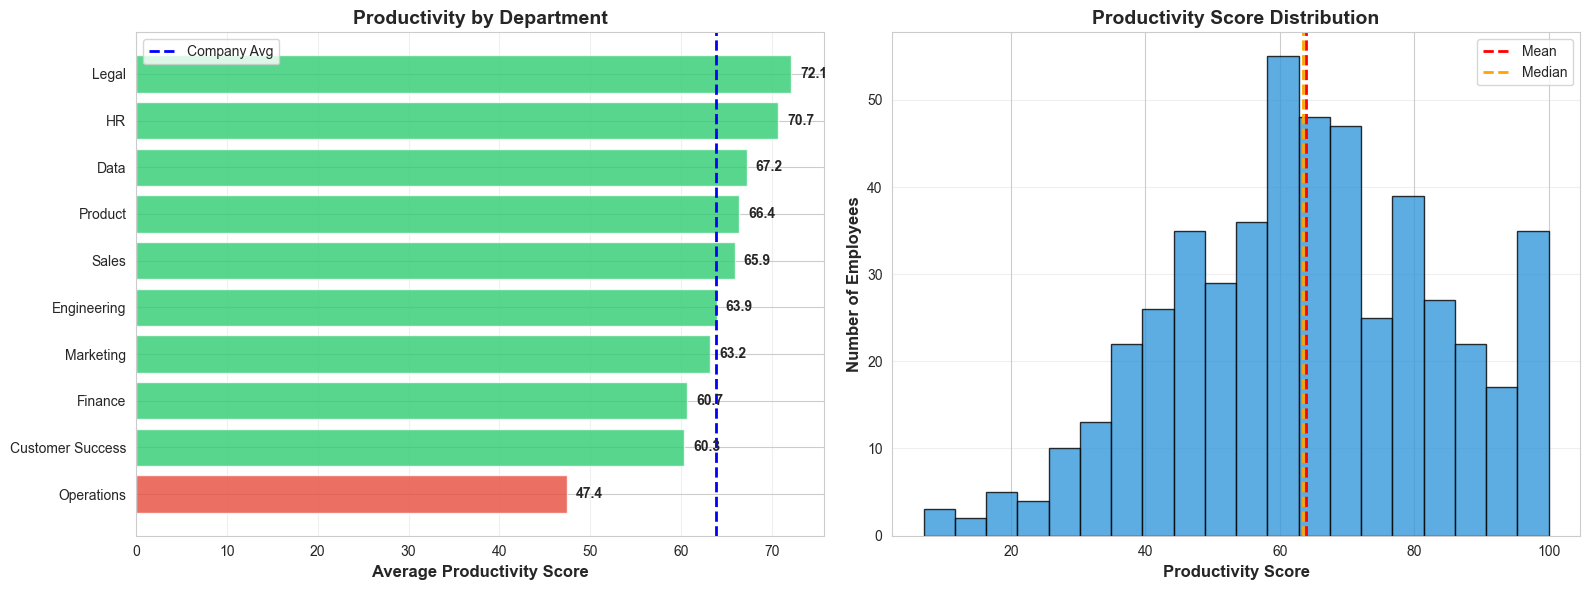

In [3]:
# Visualize productivity by department
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
dept_order = dept_productivity.index.tolist()
colors = ['#2ecc71' if x >= 60 else '#f39c12' if x >= 50 else '#e74c3c' for x in dept_productivity['mean']]
bars = ax1.barh(range(len(dept_productivity)), dept_productivity['mean'], color=colors, alpha=0.8)
ax1.set_yticks(range(len(dept_productivity)))
ax1.set_yticklabels(dept_order)
ax1.set_xlabel('Average Productivity Score', fontsize=12, fontweight='bold')
ax1.set_title('Productivity by Department', fontsize=14, fontweight='bold')
ax1.axvline(prod_analysis['productivity_score'].mean(), color='blue', linestyle='--', linewidth=2, label='Company Avg')
ax1.legend()
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, val in enumerate(dept_productivity['mean']):
    ax1.text(val + 1, i, f'{val:.1f}', va='center', fontweight='bold')

# Distribution histogram
ax2.hist(prod_analysis['productivity_score'], bins=20, color='#3498db', alpha=0.8, edgecolor='black')
ax2.axvline(prod_analysis['productivity_score'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
ax2.axvline(prod_analysis['productivity_score'].median(), color='orange', linestyle='--', linewidth=2, label='Median')
ax2.set_xlabel('Productivity Score', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Employees', fontsize=12, fontweight='bold')
ax2.set_title('Productivity Score Distribution', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Productivity Score Distribution & Department Comparison

In [4]:
# Productivity by performance rating
prod_by_rating = prod_analysis.groupby('latest_rating')['productivity_score'].agg(['mean', 'std', 'count']).round(1)

print("\nPRODUCTIVITY BY PERFORMANCE RATING")
print("="*70)
print(f"{'Rating':<12} {'Avg Productivity':<20} {'Std Dev':<15} {'Count':<10}")
print("="*70)
for rating in [5, 4, 3, 2, 1]:
    if rating in prod_by_rating.index:
        row = prod_by_rating.loc[rating]
        print(f"{rating:<12} {row['mean']:<20} {row['std']:<15} {int(row['count']):<10}")
print("="*70)

# Correlation
correlation = prod_analysis['latest_rating'].corr(prod_analysis['productivity_score'])
print(f"\nCorrelation (Performance × Productivity): {correlation:.3f}")
print("\nInterpretation:")
print("  r > 0.6: Strong alignment (productivity drives ratings)")
print("  r 0.4-0.6: Moderate alignment")
print("  r < 0.4: Weak alignment (other factors influence ratings)")

if correlation < 0.4:
    print("\n⚠️ Weak correlation suggests performance ratings may not reflect objective output")
elif correlation < 0.6:
    print("\n✓ Moderate correlation - mix of quantitative and qualitative factors")
else:
    print("\n✓ Strong correlation - ratings align well with productivity")


PRODUCTIVITY BY PERFORMANCE RATING
Rating       Avg Productivity     Std Dev         Count     
5            96.0                 5.8             36        
4            79.8                 10.5            142       
3            59.9                 10.4            226       
2            40.1                 9.3             84        
1            19.3                 9.4             12        

Correlation (Performance × Productivity): 0.866

Interpretation:
  r > 0.6: Strong alignment (productivity drives ratings)
  r 0.4-0.6: Moderate alignment
  r < 0.4: Weak alignment (other factors influence ratings)

✓ Strong correlation - ratings align well with productivity


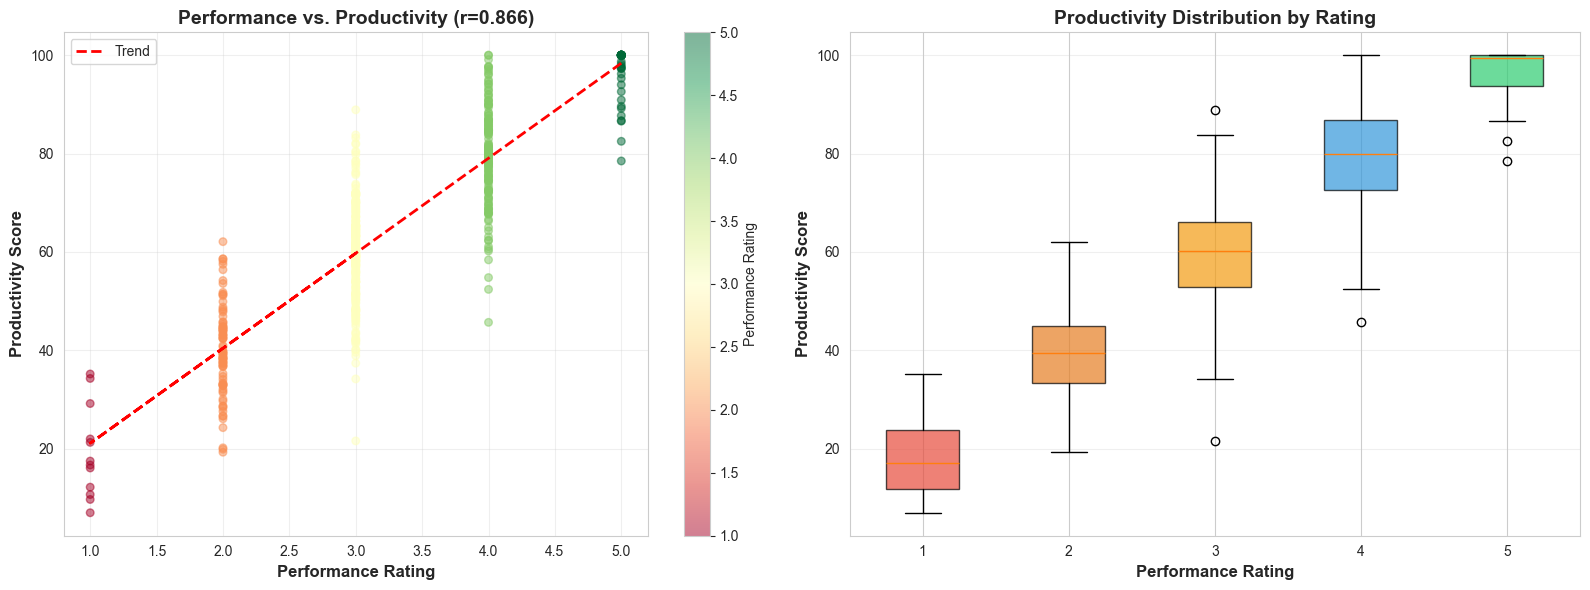

In [5]:
# Visualize productivity vs performance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
scatter = ax1.scatter(prod_analysis['latest_rating'], prod_analysis['productivity_score'], 
                     alpha=0.5, s=30, c=prod_analysis['latest_rating'], cmap='RdYlGn')
ax1.set_xlabel('Performance Rating', fontsize=12, fontweight='bold')
ax1.set_ylabel('Productivity Score', fontsize=12, fontweight='bold')
ax1.set_title(f'Performance vs. Productivity (r={correlation:.3f})', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='Performance Rating')

# Add trend line
z = np.polyfit(prod_analysis['latest_rating'], prod_analysis['productivity_score'], 1)
p = np.poly1d(z)
ax1.plot(prod_analysis['latest_rating'], p(prod_analysis['latest_rating']), "r--", linewidth=2, label='Trend')
ax1.legend()

# Box plot by rating
data_for_box = [prod_analysis[prod_analysis['latest_rating'] == r]['productivity_score'] for r in [1, 2, 3, 4, 5]]
bp = ax2.boxplot(data_for_box, labels=[1, 2, 3, 4, 5], patch_artist=True)

# Color boxes
colors = ['#e74c3c', '#e67e22', '#f39c12', '#3498db', '#2ecc71']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_xlabel('Performance Rating', fontsize=12, fontweight='bold')
ax2.set_ylabel('Productivity Score', fontsize=12, fontweight='bold')
ax2.set_title('Productivity Distribution by Rating', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Productivity vs. Performance Correlation

In [6]:
# Calculate trajectory for employees with 2+ reviews
employee_reviews = reviews.sort_values(['employee_id', 'review_date'])
employee_reviews_count = employee_reviews.groupby('employee_id').size()
employees_with_history = employee_reviews_count[employee_reviews_count >= 2].index

trajectories = []
for emp_id in employees_with_history:
    emp_reviews = employee_reviews[employee_reviews['employee_id'] == emp_id].sort_values('review_date')
    first_rating = emp_reviews.iloc[0]['rating_numeric']
    last_rating = emp_reviews.iloc[-1]['rating_numeric']
    change = last_rating - first_rating
    
    if change > 0.5:
        trajectory = 'Improving'
    elif change < -0.5:
        trajectory = 'Declining'
    else:
        trajectory = 'Stable'
    
    trajectories.append({
        'employee_id': emp_id,
        'first_rating': first_rating,
        'last_rating': last_rating,
        'rating_change': change,
        'trajectory': trajectory,
        'num_reviews': len(emp_reviews)
    })

trajectory_df = pd.DataFrame(trajectories)

# Summary
trajectory_counts = trajectory_df['trajectory'].value_counts()

print("\nPERFORMANCE TRAJECTORY ANALYSIS")
print("="*70)
print(f"Employees with trajectory data: {len(trajectory_df)}")
print("\nTrajectory Distribution:")
for traj in ['Improving', 'Stable', 'Declining']:
    count = trajectory_counts.get(traj, 0)
    pct = count / len(trajectory_df) * 100
    print(f"  {traj}: {count} ({pct:.1f}%)")
print("="*70)

# Highlight improving and declining employees
improving = trajectory_df[trajectory_df['trajectory'] == 'Improving'].sort_values('rating_change', ascending=False)
declining = trajectory_df[trajectory_df['trajectory'] == 'Declining'].sort_values('rating_change')

print(f"\nTop 5 Most Improved:")
for _, row in improving.head(5).iterrows():
    print(f"  Employee {row['employee_id']}: {row['first_rating']} → {row['last_rating']} (+{row['rating_change']:.1f})")

print(f"\nTop 5 Most Declined:")
for _, row in declining.head(5).iterrows():
    print(f"  Employee {row['employee_id']}: {row['first_rating']} → {row['last_rating']} ({row['rating_change']:.1f})")


PERFORMANCE TRAJECTORY ANALYSIS
Employees with trajectory data: 500

Trajectory Distribution:
  Improving: 79 (15.8%)
  Stable: 330 (66.0%)
  Declining: 91 (18.2%)

Top 5 Most Improved:
  Employee 1077: 2 → 4 (+2.0)
  Employee 1006: 1 → 2 (+1.0)
  Employee 1388: 2 → 3 (+1.0)
  Employee 1384: 3 → 4 (+1.0)
  Employee 1376: 3 → 4 (+1.0)

Top 5 Most Declined:
  Employee 1330: 4 → 2 (-2.0)
  Employee 1002: 5 → 4 (-1.0)
  Employee 1356: 4 → 3 (-1.0)
  Employee 1346: 5 → 4 (-1.0)
  Employee 1343: 4 → 3 (-1.0)


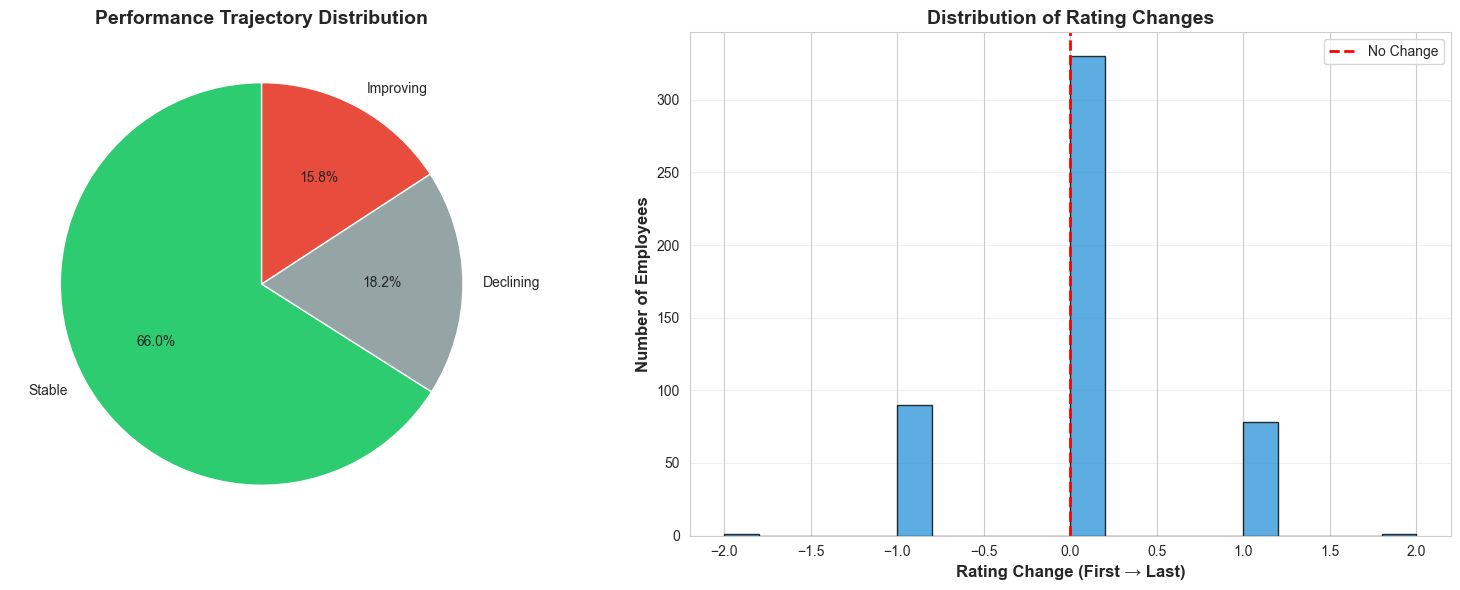

In [7]:
# Visualize trajectories
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart
colors = ['#2ecc71', '#95a5a6', '#e74c3c']
ax1.pie(trajectory_counts, labels=trajectory_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90)
ax1.set_title('Performance Trajectory Distribution', fontsize=14, fontweight='bold')

# Histogram of rating changes
ax2.hist(trajectory_df['rating_change'], bins=20, color='#3498db', alpha=0.8, edgecolor='black')
ax2.axvline(0, color='red', linestyle='--', linewidth=2, label='No Change')
ax2.set_xlabel('Rating Change (First → Last)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Employees', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of Rating Changes', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Performance Trajectory Analysis

In [8]:
# PIP analysis
print("\nPERFORMANCE IMPROVEMENT PLAN (PIP) ANALYSIS")
print("="*70)
print(f"Total PIPs: {len(pips)}")
print(f"Active PIPs: {len(pips[pips['status'] == 'In Progress'])}")
print(f"Completed PIPs: {len(pips[pips['status'] == 'Completed'])}")
print(f"Terminated: {len(pips[pips['status'] == 'Terminated'])}")
print("="*70)

# Outcomes
completed_pips = pips[pips['status'].isin(['Completed', 'Terminated'])]
outcome_counts = completed_pips['outcome'].value_counts()

print("\nPIP Outcomes:")
for outcome, count in outcome_counts.items():
    pct = count / len(completed_pips) * 100
    print(f"  {outcome}: {count} ({pct:.1f}%)")

# Average duration
avg_duration = pips['pip_duration_days'].mean()
print(f"\nAverage PIP Duration: {avg_duration:.0f} days")

# Success rate
improved = outcome_counts.get('Improved', 0)
success_rate = improved / len(completed_pips) * 100 if len(completed_pips) > 0 else 0
print(f"\nPIP Success Rate (Improved): {success_rate:.1f}%")
print("\nInterpretation:")
print("  > 40%: Good - PIPs are effective at driving improvement")
print("  20-40%: Fair - Some improvement but many don't succeed")
print("  < 20%: Low - PIPs may be used too late or not effectively")

if success_rate < 20:
    print("\n⚠️ Low success rate suggests PIPs may be initiated too late")
    print("   → Consider earlier intervention with coaching")
elif success_rate < 40:
    print("\n⚠️ Moderate success rate - review PIP structure and support")
else:
    print("\n✓ Good PIP effectiveness")


PERFORMANCE IMPROVEMENT PLAN (PIP) ANALYSIS
Total PIPs: 63
Active PIPs: 18
Completed PIPs: 27
Terminated: 18

PIP Outcomes:
  Exited: 18 (40.0%)
  Improved: 15 (33.3%)
  No Improvement: 12 (26.7%)

Average PIP Duration: 90 days

PIP Success Rate (Improved): 33.3%

Interpretation:
  > 40%: Good - PIPs are effective at driving improvement
  20-40%: Fair - Some improvement but many don't succeed
  < 20%: Low - PIPs may be used too late or not effectively

⚠️ Moderate success rate - review PIP structure and support


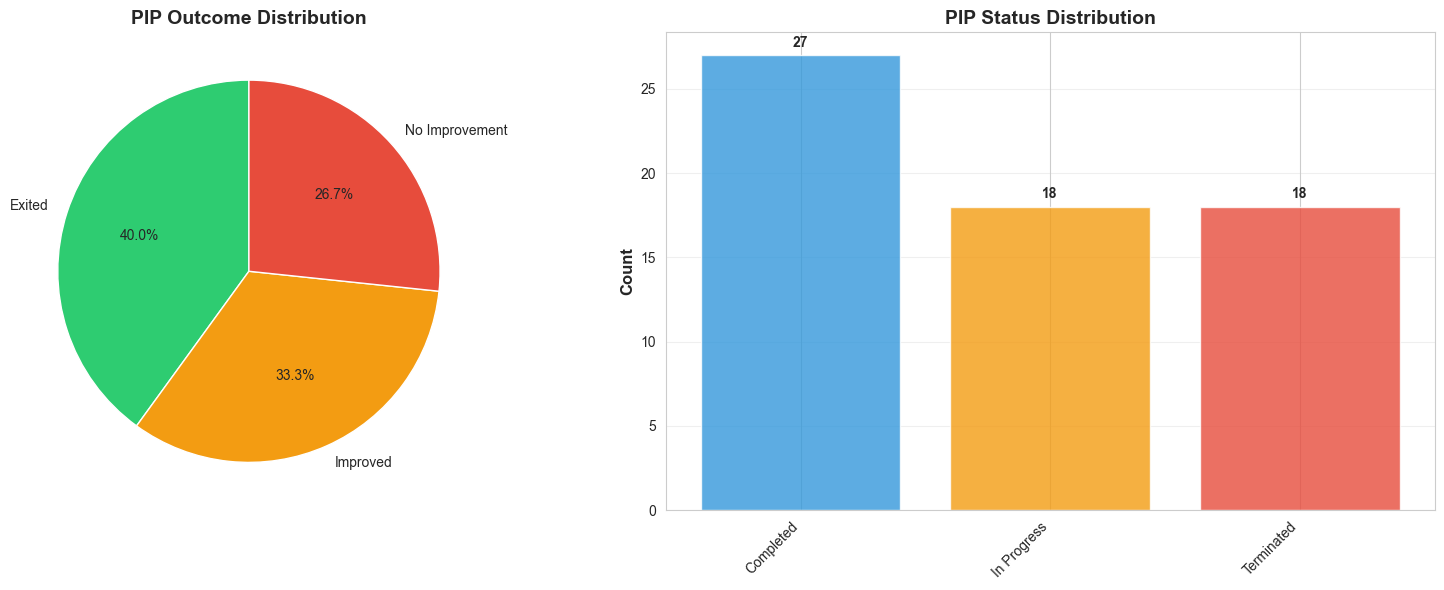

In [9]:
# Visualize PIP outcomes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart of outcomes
colors = ['#2ecc71', '#f39c12', '#e74c3c']
ax1.pie(outcome_counts, labels=outcome_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90)
ax1.set_title('PIP Outcome Distribution', fontsize=14, fontweight='bold')

# Status bar chart
status_counts = pips['status'].value_counts()
colors_status = {'In Progress': '#f39c12', 'Completed': '#3498db', 'Terminated': '#e74c3c'}
bar_colors = [colors_status.get(s, '#95a5a6') for s in status_counts.index]
ax2.bar(range(len(status_counts)), status_counts.values, color=bar_colors, alpha=0.8)
ax2.set_xticks(range(len(status_counts)))
ax2.set_xticklabels(status_counts.index, rotation=45, ha='right')
ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
ax2.set_title('PIP Status Distribution', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for i, val in enumerate(status_counts.values):
    ax2.text(i, val + 0.5, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Performance Improvement Plan (PIP) Effectiveness

## 6. Key Recommendations

In [10]:
print("\n" + "="*80)
print("KEY RECOMMENDATIONS")
print("="*80)

print("\n1. PRODUCTIVITY OPTIMIZATION")
low_prod_depts = dept_productivity[dept_productivity['mean'] < prod_analysis['productivity_score'].mean()]
if len(low_prod_depts) > 0:
    print(f"   → {len(low_prod_depts)} departments below average productivity:")
    for dept in low_prod_depts.index[:3]:
        print(f"      - {dept}: {dept_productivity.loc[dept, 'mean']:.1f} (vs company avg {prod_analysis['productivity_score'].mean():.1f})")
    print("   → Actions: Process improvement, tool optimization, workload balancing")

print("\n2. PERFORMANCE-PRODUCTIVITY ALIGNMENT")
print(f"   → Correlation: {correlation:.3f}")
if correlation < 0.5:
    print("   ⚠️ Consider incorporating productivity metrics into performance reviews")
    print("   → Ensure ratings reflect objective output, not just subjective factors")
else:
    print("   ✓ Good alignment between productivity and performance ratings")

print("\n3. PERFORMANCE TRAJECTORY INTERVENTION")
declining_count = len(trajectory_df[trajectory_df['trajectory'] == 'Declining'])
declining_pct = declining_count / len(trajectory_df) * 100
print(f"   → {declining_count} employees ({declining_pct:.1f}%) with declining performance")
if declining_pct > 15:
    print("   ⚠️ High rate of declining performance - investigate systemic issues")
    print("   → Possible causes: Manager effectiveness, workload, engagement, skills gaps")
else:
    print("   → Early intervention with coaching before formal PIPs")

print("\n4. PIP EFFECTIVENESS")
success_rate = outcome_counts.get('Improved', 0) / len(completed_pips) * 100 if len(completed_pips) > 0 else 0
print(f"   → PIP success rate: {success_rate:.1f}%")
active_pips = len(pips[pips['status'] == 'In Progress'])
print(f"   → {active_pips} employees currently on PIPs")
if success_rate < 30:
    print("   ⚠️ Low success rate - PIPs may be initiated too late")
    print("   → Implement earlier coaching and performance conversations")
    print("   → Review PIP structure and manager training")

print("\n5. RECOGNIZE HIGH PERFORMERS")
top_productivity = prod_analysis.nlargest(20, 'productivity_score')
high_prod_high_perf = top_productivity[top_productivity['latest_rating'] >= 4]
print(f"   → {len(high_prod_high_perf)} employees in top 20 productivity with high performance ratings")
print("   → Actions:")
print("     - Recognition programs")
print("     - Retention bonuses")
print("     - Fast-track promotions")
print("     - Share best practices across teams")

print("\n" + "="*80)
print("DOMAIN 4 ANALYSIS COMPLETE")
print("="*80)
print("\nThis concludes the Performance & Productivity analysis.")
print("Review all three notebooks for comprehensive performance insights:")
print("  1. Performance calibration and rating consistency")
print("  2. High performer retention and 9-box talent matrix")
print("  3. Productivity analysis and performance trends")
print("="*80)


KEY RECOMMENDATIONS

1. PRODUCTIVITY OPTIMIZATION
   → 4 departments below average productivity:
      - Marketing: 63.2 (vs company avg 63.8)
      - Finance: 60.7 (vs company avg 63.8)
      - Customer Success: 60.3 (vs company avg 63.8)
   → Actions: Process improvement, tool optimization, workload balancing

2. PERFORMANCE-PRODUCTIVITY ALIGNMENT
   → Correlation: 0.866
   ✓ Good alignment between productivity and performance ratings

3. PERFORMANCE TRAJECTORY INTERVENTION
   → 91 employees (18.2%) with declining performance
   ⚠️ High rate of declining performance - investigate systemic issues
   → Possible causes: Manager effectiveness, workload, engagement, skills gaps

4. PIP EFFECTIVENESS
   → PIP success rate: 33.3%
   → 18 employees currently on PIPs

5. RECOGNIZE HIGH PERFORMERS
   → 20 employees in top 20 productivity with high performance ratings
   → Actions:
     - Recognition programs
     - Retention bonuses
     - Fast-track promotions
     - Share best practices acr